# 🔍 AI-Powered Image Analyzer

> **Stack:** AWS Lambda · Amazon Rekognition · Amazon Bedrock (Mistral) · API Gateway · S3 · Terraform


This notebook is the **single-file, self-contained companion** to the project.

Running every cell top-to-bottom will:

1. Recreate the full project file-tree inside Colab

2. Package the Lambda deployment archive

3. Walk you through the complete AWS + Terraform deployment

4. Produce a production-ready `README.md`

5. Bundle everything into a timestamped ZIP for download


---

**Runtime requirement:** Python 3.10+, internet access (for `pip` installs). No AWS credentials are needed just to *generate* the files — they are only required at deployment time.


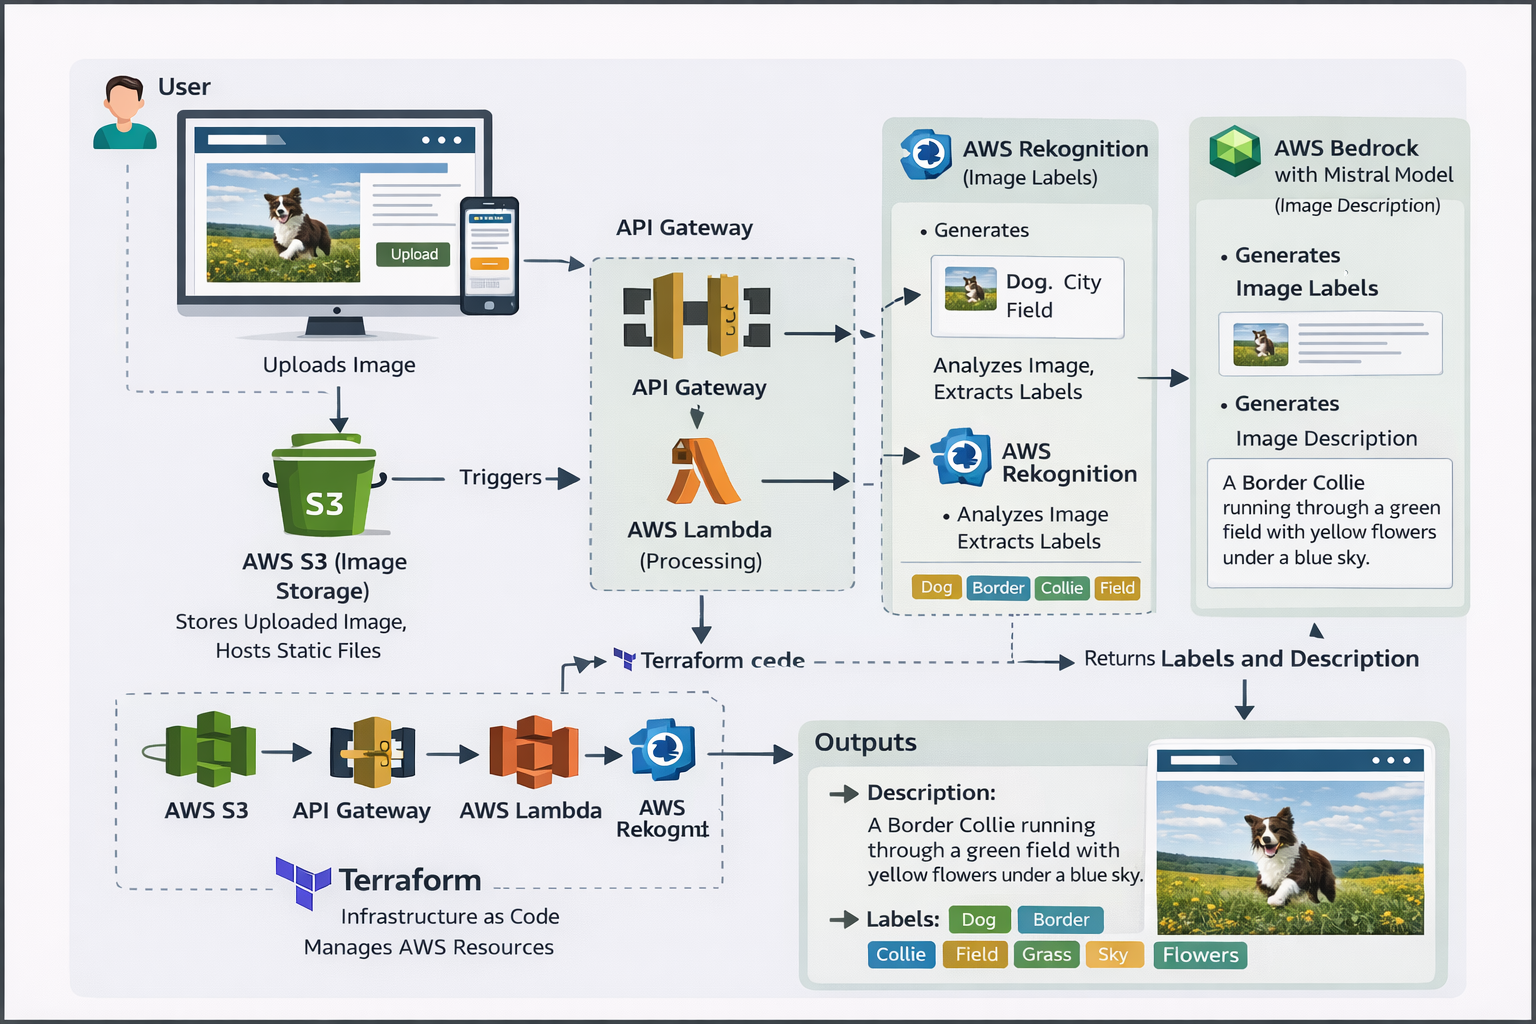

In [16]:
# Display image in Google Colab

from IPython.display import Image, display

display(Image(filename='/content/Architecture.png'))

## 🔧 Section 1 — Environment Bootstrap

In [1]:
# ── Runtime sanity-check ──────────────────────────────────────────────────
# Verifies Python version and confirms we are inside a Colab/Jupyter kernel.
import sys, platform, textwrap

print('Python  :', sys.version)
print('Platform:', platform.platform())

if sys.version_info < (3, 8):
    raise RuntimeError('Python 3.8+ is required. Please switch the Colab runtime.')

print('\n✅  Runtime check passed.')

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35

✅  Runtime check passed.


In [2]:
# ── Standard-library imports (no pip needed) ──────────────────────────────
# All modules used throughout the notebook are imported once here so that
# later cells remain focused on business logic rather than housekeeping.
import os
import json
import shutil
import zipfile
import textwrap
import datetime
import pathlib

print('✅  Standard-library imports loaded.')

✅  Standard-library imports loaded.


## 📁 Section 2 — Project File-Tree Creation

In [3]:
# ── Define the canonical project directory structure ──────────────────────
# Every path is relative to PROJECT_ROOT so the notebook is portable across
# Colab, local Jupyter, and VS Code environments.

PROJECT_ROOT = pathlib.Path('/content/ai-image-analyzer')

DIRS = [
    PROJECT_ROOT / 'CODE' / 'lambda',
    PROJECT_ROOT / 'CODE' / 'terraform',
    PROJECT_ROOT / 'CODE' / 'frontend',
    PROJECT_ROOT / 'ARCHITECTURE',
    PROJECT_ROOT / 'OUTPUT',
]

for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)
    print(f'  Created  {d.relative_to(PROJECT_ROOT)}')

print(f'\n✅  Project root → {PROJECT_ROOT}')

  Created  CODE/lambda
  Created  CODE/terraform
  Created  CODE/frontend
  Created  ARCHITECTURE
  Created  OUTPUT

✅  Project root → /content/ai-image-analyzer


## ⚡ Section 3 — Lambda Function Source

In [4]:
# ── Write image_analyzer.py to disk ─────────────────────────────────────
# This is the core AWS Lambda handler that:
#   1. Receives a base-64 encoded image from API Gateway
#   2. Calls Amazon Rekognition to detect object labels
#   3. Passes those labels to Amazon Bedrock (Mistral) for a natural-language
#      description of the image
#   4. Returns a JSON response with labels + description

LAMBDA_SOURCE = '''import json
import boto3
import base64


rekognition = boto3.client("rekognition")
bedrock_runtime = boto3.client("bedrock-runtime")


def lambda_handler(event, context):

    cors_headers = {
        "Access-Control-Allow-Origin": "*",
        "Access-Control-Allow-Headers": "Content-Type",
        "Access-Control-Allow-Methods": "OPTIONS,POST"
    }

    try:

        body = json.loads(event.get("body", "{}"))
        image_base64 = body.get("image")

        if not image_base64:
            return {
                "statusCode": 400,
                "headers": cors_headers,
                "body": json.dumps({"error": "No image provided"})
            }

        image_bytes = base64.b64decode(image_base64)


        rekognition_response = rekognition.detect_labels(
            Image={"Bytes": image_bytes},
            MaxLabels=10,
            MinConfidence=80
        )

        labels = [label["Name"] for label in rekognition_response["Labels"]]

        if not labels:
            return {
                "statusCode": 200,
                "headers": cors_headers,
                "body": json.dumps({
                    "labels": [],
                    "description": "No labels detected."
                })
            }


        prompt = (
            f"Based on these labels: {', '.join(labels)}. "
            f"Generate ONE clear and natural English sentence describing the image."
        )


        bedrock_payload = {
            "prompt": prompt,
            "max_tokens": 100,
            "temperature": 0.5,
            "top_p": 0.9
        }

        bedrock_response = bedrock_runtime.invoke_model(
            body=json.dumps(bedrock_payload),
            modelId="mistral.mistral-small-2402-v1:0",
            contentType="application/json",
            accept="application/json"
        )

        response_body = json.loads(
            bedrock_response["body"].read()
        )

        description = response_body["outputs"][0]["text"].strip()


        return {
            "statusCode": 200,
            "headers": cors_headers,
            "body": json.dumps({
                "labels": labels,
                "description": description
            })
        }

    except Exception as e:
        print("ERROR:", str(e))

        return {
            "statusCode": 500,
            "headers": cors_headers,
            "body": json.dumps({
                "error": str(e)
            })
        }'''

lambda_path = PROJECT_ROOT / 'CODE' / 'lambda' / 'image_analyzer.py'
lambda_path.write_text(LAMBDA_SOURCE)
print(f'✅  Lambda source written → {lambda_path}')
print(f'    Lines: {len(LAMBDA_SOURCE.splitlines())}')

✅  Lambda source written → /content/ai-image-analyzer/CODE/lambda/image_analyzer.py
    Lines: 97


## 🏗️ Section 4 — Terraform Infrastructure-as-Code

In [5]:
# ── Write terraform/main.tf ───────────────────────────────────────────────
# Provisions all AWS resources required by the project:
#   • IAM Role + Policies  (Lambda execution, Rekognition, Bedrock, CloudWatch)
#   • Lambda Function       (Python 3.9 runtime, 30 s timeout)
#   • API Gateway REST API  (POST /analyze + OPTIONS CORS pre-flight)
#   • S3 Bucket             (static website for the React/HTML frontend)

MAIN_TF = '''terraform {
  required_providers {
    aws = {
      source  = "hashicorp/aws"
      version = "~> 5.0"
    }
  }
}

provider "aws" {
  region = var.aws_region
}


resource "aws_iam_role" "lambda_exec_role" {
  name = "${var.project_name}-lambda-exec-role"

  assume_role_policy = jsonencode({
    Version = "2012-10-17",
    Statement = [{
      Action = "sts:AssumeRole",
      Effect = "Allow",
      Principal = {
        Service = "lambda.amazonaws.com"
      }
    }]
  })
}

resource "aws_iam_policy" "lambda_logging_policy" {
  name        = "${var.project_name}-lambda-logging-policy"
  description = "IAM policy for Lambda logs"

  policy = jsonencode({
    Version = "2012-10-17",
    Statement = [{
      Action = [
        "logs:CreateLogGroup",
        "logs:CreateLogStream",
        "logs:PutLogEvents"
      ],
      Effect   = "Allow",
      Resource = "arn:aws:logs:*:*:*"
    }]
  })
}

resource "aws_iam_policy" "lambda_ai_services_policy" {
  name        = "${var.project_name}-ai-services-policy"
  description = "IAM policy for Rekognition + Bedrock"

  policy = jsonencode({
    Version = "2012-10-17",
    Statement = [
      {
        Action   = "rekognition:DetectLabels",
        Effect   = "Allow",
        Resource = "*"
      },
      {
        Action   = "bedrock:InvokeModel",
        Effect   = "Allow",
        Resource = "*"
      }
    ]
  })
}

resource "aws_iam_role_policy_attachment" "lambda_logs_attach" {
  role       = aws_iam_role.lambda_exec_role.name
  policy_arn = aws_iam_policy.lambda_logging_policy.arn
}

resource "aws_iam_role_policy_attachment" "lambda_ai_services_attach" {
  role       = aws_iam_role.lambda_exec_role.name
  policy_arn = aws_iam_policy.lambda_ai_services_policy.arn
}


data "archive_file" "lambda_zip" {
  type        = "zip"
  source_dir  = "../lambda/"
  output_path = "${path.module}/image_analyzer.zip"
}

resource "aws_lambda_function" "image_analyzer_lambda" {
  filename         = data.archive_file.lambda_zip.output_path
  function_name    = "${var.project_name}-function"
  role             = aws_iam_role.lambda_exec_role.arn
  handler          = "image_analyzer.lambda_handler"
  runtime          = "python3.9"
  timeout          = 30
  source_code_hash = data.archive_file.lambda_zip.output_base64sha256
}


resource "aws_api_gateway_rest_api" "api" {
  name        = "${var.project_name}-api"
  description = "API for Image Analyzer"
}

resource "aws_api_gateway_resource" "resource" {
  rest_api_id = aws_api_gateway_rest_api.api.id
  parent_id   = aws_api_gateway_rest_api.api.root_resource_id
  path_part   = "analyze"
}

resource "aws_api_gateway_method" "method" {
  rest_api_id   = aws_api_gateway_rest_api.api.id
  resource_id   = aws_api_gateway_resource.resource.id
  http_method   = "POST"
  authorization = "NONE"
}

resource "aws_api_gateway_integration" "integration" {
  rest_api_id             = aws_api_gateway_rest_api.api.id
  resource_id             = aws_api_gateway_resource.resource.id
  http_method             = aws_api_gateway_method.method.http_method
  integration_http_method = "POST"
  type                    = "AWS_PROXY"
  uri                     = aws_lambda_function.image_analyzer_lambda.invoke_arn
}


resource "aws_api_gateway_method" "options_method" {
  rest_api_id   = aws_api_gateway_rest_api.api.id
  resource_id   = aws_api_gateway_resource.resource.id
  http_method   = "OPTIONS"
  authorization = "NONE"
}

resource "aws_api_gateway_integration" "options_integration" {
  rest_api_id = aws_api_gateway_rest_api.api.id
  resource_id = aws_api_gateway_resource.resource.id
  http_method = aws_api_gateway_method.options_method.http_method
  type        = "MOCK"

  request_templates = {
    "application/json" = "{\\"statusCode\\": 200}"
  }
}

resource "aws_api_gateway_method_response" "options_response" {
  rest_api_id = aws_api_gateway_rest_api.api.id
  resource_id = aws_api_gateway_resource.resource.id
  http_method = aws_api_gateway_method.options_method.http_method
  status_code = "200"

  response_parameters = {
    "method.response.header.Access-Control-Allow-Headers" = true,
    "method.response.header.Access-Control-Allow-Methods" = true,
    "method.response.header.Access-Control-Allow-Origin"  = true
  }
}

resource "aws_api_gateway_integration_response" "options_integration_response" {
  rest_api_id = aws_api_gateway_rest_api.api.id
  resource_id = aws_api_gateway_resource.resource.id
  http_method = aws_api_gateway_method.options_method.http_method
  status_code = aws_api_gateway_method_response.options_response.status_code

  response_parameters = {
    "method.response.header.Access-Control-Allow-Headers" = "'Content-Type,X-Amz-Date,Authorization,X-Api-Key,X-Amz-Security-Token'"
    "method.response.header.Access-Control-Allow-Methods" = "'OPTIONS,POST'"
    "method.response.header.Access-Control-Allow-Origin"  = "'*'"
  }

  depends_on = [aws_api_gateway_integration.options_integration]
}

resource "aws_lambda_permission" "api_gateway_permission" {
  statement_id  = "AllowAPIGatewayInvoke"
  action        = "lambda:InvokeFunction"
  function_name = aws_lambda_function.image_analyzer_lambda.function_name
  principal     = "apigateway.amazonaws.com"
  source_arn    = "${aws_api_gateway_rest_api.api.execution_arn}/*/*"
}

resource "aws_api_gateway_deployment" "deployment" {
  rest_api_id = aws_api_gateway_rest_api.api.id

  depends_on = [
    aws_api_gateway_method.method,
    aws_api_gateway_integration.integration,
    aws_api_gateway_method.options_method,
    aws_api_gateway_integration.options_integration,
    aws_api_gateway_method_response.options_response,
    aws_api_gateway_integration_response.options_integration_response
  ]

  triggers = {
    redeployment = sha1(jsonencode([
      aws_api_gateway_method.method.id,
      aws_api_gateway_integration.integration.id,
      aws_api_gateway_method.options_method.id,
      aws_api_gateway_integration.options_integration.id
    ]))
  }

  lifecycle {
    create_before_destroy = true
  }
}

resource "aws_api_gateway_stage" "stage" {
  deployment_id = aws_api_gateway_deployment.deployment.id
  rest_api_id   = aws_api_gateway_rest_api.api.id
  stage_name    = "v1"
}


resource "random_id" "bucket_suffix" {
  byte_length = 8
}

resource "aws_s3_bucket" "frontend_bucket" {
  bucket        = "${var.project_name}-frontend-${random_id.bucket_suffix.hex}"
  force_destroy = true
}

resource "aws_s3_bucket_website_configuration" "frontend_website" {
  bucket = aws_s3_bucket.frontend_bucket.id

  index_document { suffix = "index.html" }
  error_document { key = "index.html" }
}

resource "aws_s3_bucket_public_access_block" "frontend_public_access" {
  bucket                  = aws_s3_bucket.frontend_bucket.id
  block_public_acls       = false
  block_public_policy     = false
  ignore_public_acls      = false
  restrict_public_buckets = false
}

resource "aws_s3_bucket_policy" "frontend_policy" {
  bucket = aws_s3_bucket.frontend_bucket.id

  policy = jsonencode({
    Version = "2012-10-17",
    Statement = [{
      Effect    = "Allow",
      Principal = "*",
      Action    = "s3:GetObject",
      Resource  = "${aws_s3_bucket.frontend_bucket.arn}/*"
    }]
  })
}


output "frontend_website_url" {
  value = aws_s3_bucket_website_configuration.frontend_website.website_endpoint
}'''

tf_dir = PROJECT_ROOT / 'CODE' / 'terraform'
(tf_dir / 'main.tf').write_text(MAIN_TF)
print('✅  main.tf written.')

✅  main.tf written.


In [6]:
# ── Write terraform/variables.tf ──────────────────────────────────────────
# Declares all input variables so the deployment can be customised without
# touching main.tf directly.  Override via terraform.tfvars or -var flags.

VARIABLES_TF = '''variable "aws_region" {
  description = "The AWS region to deploy resources in."
  type        = string
  default     = "us-east-1"
}

variable "project_name" {
  description = "A unique name for the project to prefix resources."
  type        = string
  default     = "ai-image-analyzer"
}

variable "environment" {
  description = "Deployment environment (e.g., dev, staging, prod)"
  type        = string
  default     = "dev"
}'''

(tf_dir / 'variables.tf').write_text(VARIABLES_TF)
print('✅  variables.tf written.')

✅  variables.tf written.


In [7]:
# ── Write terraform/outputs.tf ────────────────────────────────────────────
# Exposes the four most important values after `terraform apply` completes:
#   api_gateway_url         → paste into frontend/index.html as API_ENDPOINT
#   lambda_function_name    → useful for CloudWatch logs / manual invocation
#   frontend_bucket_name    → the S3 bucket to upload index.html into
#   frontend_website_endpoint → the public URL of the hosted UI

OUTPUTS_TF = '''output "api_gateway_url" {
  description = "The invoke URL of the deployed API"
  value       = aws_api_gateway_stage.stage.invoke_url
}

output "lambda_function_name" {
  description = "The name of the Lambda function"
  value       = aws_lambda_function.image_analyzer_lambda.function_name
}

output "frontend_bucket_name" {
  description = "The name of the S3 bucket hosting the frontend"
  value       = aws_s3_bucket.frontend_bucket.bucket
}

output "frontend_website_endpoint" {
  description = "The website endpoint of the frontend S3 bucket"
  value       = aws_s3_bucket_website_configuration.frontend_website.website_endpoint
}'''

(tf_dir / 'outputs.tf').write_text(OUTPUTS_TF)
print('✅  outputs.tf written.')

✅  outputs.tf written.


## 🌐 Section 5 — Frontend Web Application

In [8]:
# ── Write frontend/index.html ─────────────────────────────────────────────
# Single-page application (VISIO) that:
#   • Accepts a PNG or JPEG upload from the user
#   • Encodes it to base-64 in the browser
#   • POSTs it to the API Gateway endpoint
#   • Renders the detected labels as animated tags
#   • Displays the Bedrock-generated AI description
#
# NOTE: Before deploying, replace the API_ENDPOINT constant in the <script>
# block with the URL printed by `terraform output api_gateway_url`.

FRONTEND_HTML = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>VISIO — AI Image Analyzer</title>
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@400;700&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">
    <style>
        *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

        :root {
            --bg: #070b14;
            --surface: rgba(255,255,255,0.04);
            --surface-hover: rgba(255,255,255,0.08);
            --border: rgba(255,255,255,0.08);
            --accent: #c9a96e;
            --accent2: #6ec9c0;
            --text: #e8e4de;
            --muted: rgba(232,228,222,0.45);
            --glow: rgba(201,169,110,0.15);
        }

        body {
            font-family: 'DM Sans', sans-serif;
            background: var(--bg);
            color: var(--text);
            min-height: 100vh;
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 40px 20px;
            overflow-x: hidden;
        }

        /* Animated background */
        body::before {
            content: '';
            position: fixed;
            inset: 0;
            background:
                radial-gradient(ellipse 80% 50% at 20% 20%, rgba(201,169,110,0.07) 0%, transparent 60%),
                radial-gradient(ellipse 60% 40% at 80% 80%, rgba(110,201,192,0.06) 0%, transparent 60%),
                radial-gradient(ellipse 40% 60% at 60% 30%, rgba(255,255,255,0.02) 0%, transparent 50%);
            pointer-events: none;
            animation: bgPulse 8s ease-in-out infinite alternate;
        }

        @keyframes bgPulse {
            from { opacity: 0.7; }
            to { opacity: 1; }
        }

        /* Floating orbs */
        .orb {
            position: fixed;
            border-radius: 50%;
            filter: blur(80px);
            pointer-events: none;
            animation: float 12s ease-in-out infinite;
        }
        .orb-1 { width: 400px; height: 400px; background: rgba(201,169,110,0.08); top: -100px; left: -100px; animation-delay: 0s; }
        .orb-2 { width: 300px; height: 300px; background: rgba(110,201,192,0.07); bottom: -80px; right: -80px; animation-delay: -4s; }
        .orb-3 { width: 200px; height: 200px; background: rgba(201,169,110,0.05); top: 50%; left: 70%; animation-delay: -8s; }

        @keyframes float {
            0%, 100% { transform: translate(0, 0) scale(1); }
            33% { transform: translate(20px, -20px) scale(1.05); }
            66% { transform: translate(-10px, 15px) scale(0.95); }
        }

        /* Grid lines */
        .grid-overlay {
            position: fixed;
            inset: 0;
            background-image:
                linear-gradient(rgba(255,255,255,0.015) 1px, transparent 1px),
                linear-gradient(90deg, rgba(255,255,255,0.015) 1px, transparent 1px);
            background-size: 60px 60px;
            pointer-events: none;
        }

        .container {
            width: 100%;
            max-width: 780px;
            position: relative;
            z-index: 1;
            animation: containerReveal 0.8s cubic-bezier(0.16, 1, 0.3, 1) both;
        }

        @keyframes containerReveal {
            from { opacity: 0; transform: translateY(30px); }
            to { opacity: 1; transform: translateY(0); }
        }

        /* Header */
        header {
            text-align: center;
            margin-bottom: 48px;
            animation: fadeUp 0.8s cubic-bezier(0.16, 1, 0.3, 1) 0.1s both;
        }

        .logo-line {
            display: flex;
            align-items: center;
            justify-content: center;
            gap: 16px;
            margin-bottom: 16px;
        }

        .logo-line::before, .logo-line::after {
            content: '';
            height: 1px;
            width: 60px;
            background: linear-gradient(90deg, transparent, var(--accent));
        }
        .logo-line::after {
            background: linear-gradient(90deg, var(--accent), transparent);
        }

        .logo-dot {
            width: 8px; height: 8px;
            border-radius: 50%;
            background: var(--accent);
            box-shadow: 0 0 12px var(--accent), 0 0 24px rgba(201,169,110,0.4);
            animation: pulse 2s ease-in-out infinite;
        }

        @keyframes pulse {
            0%, 100% { box-shadow: 0 0 12px var(--accent), 0 0 24px rgba(201,169,110,0.4); }
            50% { box-shadow: 0 0 20px var(--accent), 0 0 40px rgba(201,169,110,0.6); }
        }

        header h1 {
            font-family: 'Playfair Display', serif;
            font-size: clamp(2.2rem, 5vw, 3.2rem);
            font-weight: 700;
            letter-spacing: 0.06em;
            background: linear-gradient(135deg, #e8e4de 0%, var(--accent) 50%, #e8e4de 100%);
            background-size: 200% auto;
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            background-clip: text;
            animation: shimmer 4s linear infinite;
            margin-bottom: 12px;
        }

        @keyframes shimmer {
            to { background-position: 200% center; }
        }

        header p {
            color: var(--muted);
            font-size: 0.95rem;
            font-weight: 300;
            letter-spacing: 0.02em;
            max-width: 420px;
            margin: 0 auto;
            line-height: 1.6;
        }

        @keyframes fadeUp {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }

        /* Card */
        .card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 20px;
            padding: 36px;
            backdrop-filter: blur(20px);
            -webkit-backdrop-filter: blur(20px);
            transition: border-color 0.3s;
            animation: fadeUp 0.8s cubic-bezier(0.16, 1, 0.3, 1) 0.2s both;
        }

        .card:hover {
            border-color: rgba(201,169,110,0.2);
        }

        /* Upload area */
        .upload-area {
            margin-bottom: 24px;
        }

        #imageUpload { display: none; }

        #uploadLabel {
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            gap: 12px;
            padding: 48px 32px;
            border: 1px dashed rgba(201,169,110,0.3);
            border-radius: 14px;
            cursor: pointer;
            background: rgba(201,169,110,0.03);
            margin-bottom: 20px;
            transition: all 0.3s cubic-bezier(0.16, 1, 0.3, 1);
            position: relative;
            overflow: hidden;
        }

        #uploadLabel::before {
            content: '';
            position: absolute;
            inset: 0;
            background: radial-gradient(ellipse at center, rgba(201,169,110,0.08), transparent 70%);
            opacity: 0;
            transition: opacity 0.3s;
        }

        #uploadLabel:hover {
            border-color: rgba(201,169,110,0.6);
            background: rgba(201,169,110,0.06);
            transform: translateY(-2px);
        }

        #uploadLabel:hover::before { opacity: 1; }

        .upload-icon {
            width: 52px;
            height: 52px;
            color: var(--accent);
            transition: transform 0.3s cubic-bezier(0.34, 1.56, 0.64, 1);
        }

        #uploadLabel:hover .upload-icon { transform: translateY(-4px) scale(1.1); }

        #uploadLabel .upload-title {
            font-size: 1.1rem;
            font-weight: 500;
            color: var(--text);
        }

        #uploadLabel .upload-sub {
            font-size: 0.8rem;
            color: var(--muted);
            letter-spacing: 0.05em;
            text-transform: uppercase;
        }

        #analyzeBtn {
            width: 100%;
            padding: 16px;
            background: linear-gradient(135deg, var(--accent), #b8935a);
            color: #0a0a0a;
            border: none;
            border-radius: 12px;
            font-family: 'DM Sans', sans-serif;
            font-size: 0.95rem;
            font-weight: 500;
            letter-spacing: 0.08em;
            text-transform: uppercase;
            cursor: pointer;
            transition: all 0.3s cubic-bezier(0.16, 1, 0.3, 1);
            position: relative;
            overflow: hidden;
        }

        #analyzeBtn::after {
            content: '';
            position: absolute;
            inset: 0;
            background: linear-gradient(135deg, rgba(255,255,255,0.2), transparent);
            opacity: 0;
            transition: opacity 0.3s;
        }

        #analyzeBtn:disabled {
            background: rgba(255,255,255,0.08);
            color: var(--muted);
            cursor: not-allowed;
            box-shadow: none;
        }

        #analyzeBtn:not(:disabled):hover {
            transform: translateY(-2px);
            box-shadow: 0 8px 30px rgba(201,169,110,0.35);
        }

        #analyzeBtn:not(:disabled):hover::after { opacity: 1; }
        #analyzeBtn:not(:disabled):active { transform: translateY(0); }

        /* Preview */
        #preview {
            text-align: center;
            margin-bottom: 24px;
        }

        #imagePreview {
            max-width: 100%;
            max-height: 380px;
            border-radius: 14px;
            display: none;
            border: 1px solid var(--border);
            box-shadow: 0 20px 60px rgba(0,0,0,0.5);
            animation: imageReveal 0.5s cubic-bezier(0.16, 1, 0.3, 1) both;
        }

        @keyframes imageReveal {
            from { opacity: 0; transform: scale(0.97); }
            to { opacity: 1; transform: scale(1); }
        }

        /* Results */
        #results {
            border-radius: 14px;
            overflow: hidden;
            background: rgba(255,255,255,0.02);
            border: 1px solid var(--border);
        }

        #results.hidden { display: none; }

        .results-header {
            padding: 20px 24px;
            border-bottom: 1px solid var(--border);
            display: flex;
            align-items: center;
            gap: 10px;
        }

        .results-header h2 {
            font-family: 'Playfair Display', serif;
            font-size: 1.1rem;
            font-weight: 400;
            color: var(--accent);
            letter-spacing: 0.04em;
        }

        .status-dot {
            width: 6px; height: 6px;
            border-radius: 50%;
            background: var(--accent2);
            box-shadow: 0 0 8px var(--accent2);
            animation: pulse 1.5s ease-in-out infinite;
        }

        #resultContent { display: none; }

        .result-section {
            padding: 24px;
            border-bottom: 1px solid var(--border);
            animation: fadeUp 0.5s cubic-bezier(0.16, 1, 0.3, 1) both;
        }

        .result-section:last-child { border-bottom: none; }

        .section-label {
            font-size: 0.7rem;
            letter-spacing: 0.12em;
            text-transform: uppercase;
            color: var(--accent);
            margin-bottom: 12px;
            font-weight: 500;
        }

        #description {
            font-size: 1rem;
            line-height: 1.75;
            color: rgba(232,228,222,0.85);
            font-weight: 300;
        }

        #labels {
            display: flex;
            flex-wrap: wrap;
            gap: 8px;
        }

        .label-tag {
            background: rgba(201,169,110,0.1);
            color: var(--accent);
            border: 1px solid rgba(201,169,110,0.25);
            padding: 6px 14px;
            border-radius: 100px;
            font-size: 0.8rem;
            font-weight: 500;
            letter-spacing: 0.03em;
            transition: all 0.2s;
            animation: tagPop 0.4s cubic-bezier(0.34, 1.56, 0.64, 1) both;
        }

        .label-tag:hover {
            background: rgba(201,169,110,0.2);
            border-color: rgba(201,169,110,0.5);
            transform: translateY(-1px);
        }

        @keyframes tagPop {
            from { opacity: 0; transform: scale(0.8); }
            to { opacity: 1; transform: scale(1); }
        }

        /* Loader */
        .loader-wrap {
            padding: 40px;
            display: flex;
            flex-direction: column;
            align-items: center;
            gap: 16px;
        }

        .loader {
            width: 40px;
            height: 40px;
            position: relative;
        }

        .loader::before, .loader::after {
            content: '';
            position: absolute;
            border-radius: 50%;
            border: 2px solid transparent;
        }

        .loader::before {
            inset: 0;
            border-top-color: var(--accent);
            animation: spin 0.8s linear infinite;
        }

        .loader::after {
            inset: 6px;
            border-top-color: var(--accent2);
            animation: spin 1.2s linear infinite reverse;
        }

        @keyframes spin {
            to { transform: rotate(360deg); }
        }

        .loader-text {
            font-size: 0.8rem;
            color: var(--muted);
            letter-spacing: 0.08em;
            text-transform: uppercase;
            animation: blink 1.5s ease-in-out infinite;
        }

        @keyframes blink {
            0%, 100% { opacity: 0.5; }
            50% { opacity: 1; }
        }

        /* Footer */
        footer {
            text-align: center;
            margin-top: 36px;
            font-size: 0.75rem;
            color: rgba(232,228,222,0.2);
            letter-spacing: 0.08em;
            text-transform: uppercase;
            animation: fadeUp 0.8s cubic-bezier(0.16, 1, 0.3, 1) 0.4s both;
        }

        /* Staggered tag animation */
        .label-tag:nth-child(1) { animation-delay: 0.05s; }
        .label-tag:nth-child(2) { animation-delay: 0.1s; }
        .label-tag:nth-child(3) { animation-delay: 0.15s; }
        .label-tag:nth-child(4) { animation-delay: 0.2s; }
        .label-tag:nth-child(5) { animation-delay: 0.25s; }
        .label-tag:nth-child(6) { animation-delay: 0.3s; }
        .label-tag:nth-child(7) { animation-delay: 0.35s; }
        .label-tag:nth-child(8) { animation-delay: 0.4s; }
    </style>
</head>
<body>
    <div class="orb orb-1"></div>
    <div class="orb orb-2"></div>
    <div class="orb orb-3"></div>
    <div class="grid-overlay"></div>

    <div class="container">
        <header>
            <div class="logo-line">
                <div class="logo-dot"></div>
            </div>
            <h1>VISIO</h1>
            <p>Upload an image to detect labels with AWS Rekognition and receive an AI-generated description from Amazon Bedrock.</p>
        </header>

        <div class="card">
            <div class="upload-area">
                <input type="file" id="imageUpload" accept="image/png, image/jpeg">
                <label for="imageUpload" id="uploadLabel">
                    <svg class="upload-icon" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round">
                        <path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/>
                        <polyline points="17 8 12 3 7 8"/>
                        <line x1="12" y1="3" x2="12" y2="15"/>
                    </svg>
                    <span class="upload-title">Drop your image here</span>
                    <span class="upload-sub">PNG or JPEG accepted</span>
                </label>
                <button id="analyzeBtn" disabled>Analyze Image</button>
            </div>

            <div id="preview">
                <img id="imagePreview" src="#" alt="Image Preview">
            </div>

            <div id="results" class="hidden">
                <div class="results-header">
                    <div class="status-dot"></div>
                    <h2>Analysis Results</h2>
                </div>
                <div class="loader-wrap" id="loader">
                    <div class="loader"></div>
                    <span class="loader-text">Analyzing&hellip;</span>
                </div>
                <div id="resultContent">
                    <div class="result-section">
                        <div class="section-label">AI Description</div>
                        <p id="description"></p>
                    </div>
                    <div class="result-section">
                        <div class="section-label">Detected Labels</div>
                        <div id="labels"></div>
                    </div>
                </div>
            </div>
        </div>

        <footer>
            <p>Built with AWS Rekognition &nbsp;·&nbsp; Bedrock &nbsp;·&nbsp; Terraform</p>
        </footer>
    </div>

    <script>
        document.addEventListener('DOMContentLoaded', () => {
            const imageUpload = document.getElementById('imageUpload');
            const uploadLabel = document.getElementById('uploadLabel');
            const analyzeBtn = document.getElementById('analyzeBtn');
            const imagePreview = document.getElementById('imagePreview');
            const resultsContainer = document.getElementById('results');
            const loader = document.getElementById('loader');
            const resultContent = document.getElementById('resultContent');
            const descriptionEl = document.getElementById('description');
            const labelsEl = document.getElementById('labels');

            const API_ENDPOINT = 'https://oest2wm8g3.execute-api.us-east-1.amazonaws.com/v1/analyze';

            let base64Image = null;

            imageUpload.addEventListener('change', (event) => {
                const file = event.target.files[0];
                if (file) {
                    const reader = new FileReader();
                    reader.onload = (e) => {
                        imagePreview.src = e.target.result;
                        imagePreview.style.display = 'block';
                        // Reset animation
                        imagePreview.style.animation = 'none';
                        imagePreview.offsetHeight;
                        imagePreview.style.animation = '';
                        uploadLabel.querySelector('.upload-title').textContent = file.name;
                        uploadLabel.querySelector('.upload-sub').textContent = 'Ready to analyze';
                        analyzeBtn.disabled = false;
                    };
                    reader.readAsDataURL(file);

                    const readerForBase64 = new FileReader();
                    readerForBase64.onload = (e) => {
                        base64Image = e.target.result.split(',')[1];
                    };
                    readerForBase64.readAsDataURL(file);
                }
            });

            analyzeBtn.addEventListener('click', async () => {
                if (!base64Image || API_ENDPOINT === 'YOUR_API_GATEWAY_INVOKE_URL') {
                    alert('Please select an image first or configure the API endpoint.');
                    return;
                }

                resultsContainer.classList.remove('hidden');
                loader.style.display = 'flex';
                resultContent.style.display = 'none';
                descriptionEl.textContent = '';
                labelsEl.innerHTML = '';

                try {
                    const response = await fetch(API_ENDPOINT, {
                        method: 'POST',
                        headers: { 'Content-Type': 'application/json' },
                        body: JSON.stringify({ image: base64Image }),
                    });

                    if (!response.ok) {
                        const errorData = await response.json();
                        throw new Error(errorData.error || `HTTP error! status: ${response.status}`);
                    }

                    const data = await response.json();

                    descriptionEl.textContent = data.description;
                    data.labels.forEach((label, i) => {
                        const labelTag = document.createElement('div');
                        labelTag.className = 'label-tag';
                        labelTag.textContent = label;
                        labelTag.style.animationDelay = `${i * 0.05}s`;
                        labelsEl.appendChild(labelTag);
                    });

                } catch (error) {
                    console.error('Error:', error);
                    descriptionEl.textContent = `An error occurred: ${error.message}`;
                } finally {
                    loader.style.display = 'none';
                    resultContent.style.display = 'block';
                }
            });
        });
    </script>
</body>
</html>'''

frontend_path = PROJECT_ROOT / 'CODE' / 'frontend' / 'index.html'
frontend_path.write_text(FRONTEND_HTML)
print(f'✅  Frontend written  → {frontend_path}')
print(f'    Size: {frontend_path.stat().st_size:,} bytes')

✅  Frontend written  → /content/ai-image-analyzer/CODE/frontend/index.html
    Size: 21,087 bytes


## 📦 Section 6 — Lambda Deployment Package

In [9]:
# ── Create image_analyzer.zip (Lambda deployment package) ────────────────
# Terraform's `archive_file` data-source does this automatically during
# `terraform apply`.  This cell reproduces the same artefact locally so you
# can inspect it or upload it manually if needed.

zip_path = PROJECT_ROOT / 'CODE' / 'terraform' / 'image_analyzer.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(lambda_path, arcname='image_analyzer.py')

print(f'✅  Lambda ZIP created → {zip_path}')
print(f'    Compressed size : {zip_path.stat().st_size:,} bytes')

# Verify the archive is intact
with zipfile.ZipFile(zip_path) as zf:
    names = zf.namelist()
print(f'    Contents        : {names}')

✅  Lambda ZIP created → /content/ai-image-analyzer/CODE/terraform/image_analyzer.zip
    Compressed size : 979 bytes
    Contents        : ['image_analyzer.py']


## 🗂️ Section 7 — Project Tree Verification

In [10]:
# ── Walk the project tree and confirm every expected file exists ──────────
# A missing file here means a previous cell failed silently.

EXPECTED = [
    'CODE/lambda/image_analyzer.py',
    'CODE/terraform/main.tf',
    'CODE/terraform/variables.tf',
    'CODE/terraform/outputs.tf',
    'CODE/terraform/image_analyzer.zip',
    'CODE/frontend/index.html',
]

all_ok = True
for rel in EXPECTED:
    p = PROJECT_ROOT / rel
    status = '✅' if p.exists() else '❌ MISSING'
    if not p.exists(): all_ok = False
    print(f'  {status}  {rel}  ({p.stat().st_size:,} bytes)' if p.exists() else f'  {status}  {rel}')

if all_ok:
    print('\n✅  All files present and accounted for.')
else:
    print('\n❌  Some files are missing — re-run the corresponding section cells.')

  ✅  CODE/lambda/image_analyzer.py  (2,486 bytes)
  ✅  CODE/terraform/main.tf  (7,334 bytes)
  ✅  CODE/terraform/variables.tf  (431 bytes)
  ✅  CODE/terraform/outputs.tf  (637 bytes)
  ✅  CODE/terraform/image_analyzer.zip  (979 bytes)
  ✅  CODE/frontend/index.html  (21,087 bytes)

✅  All files present and accounted for.


---

# 🚀 Section 8 — Deployment Guide (Read This Carefully)


This section is a **step-by-step, chronological deployment handbook** written

for someone with no prior AWS or Terraform experience.

Follow every step in order — skipping one will break the next.


---


## PHASE 1 — Create Your AWS Account  

*(skip if you already have one)*


1. Open **https://aws.amazon.com** and click **Create a Free Account**.

2. Enter your email address → choose a root account password.

3. Select **Personal** account type → enter your name, phone number, and address.

4. Add a **credit / debit card** (AWS requires one even for free-tier usage;

   you will **not** be charged as long as you stay within free-tier limits).

5. Verify your phone number via SMS.

6. Choose the **Basic Support (Free)** plan.

7. Sign in to the **AWS Management Console**.


---


## PHASE 2 — Enable Amazon Bedrock Model Access


Amazon Bedrock requires explicit model opt-in before any API calls succeed.


1. In the AWS Console top-left search bar type **Bedrock** → click the service.

2. In the left sidebar click **Model access** (under *Bedrock configurations*).

3. Click **Manage model access** (top-right button).

4. Find **Mistral Small** (model ID `mistral.mistral-small-2402-v1:0`) → tick ✅.

5. Click **Request model access** → wait ~2 minutes for status to turn **Access granted**.


> ⚠️  If you skip this step Terraform deploys successfully but every Lambda

> invocation returns a 500 error with `AccessDeniedException`.


---


## PHASE 3 — Create an IAM User for Terraform (Least Privilege)


Never use your root account credentials with Terraform.


1. Console → **IAM** → **Users** → **Create user**.

2. User name: `terraform-deployer`  |  Access: **Programmatic access only**.

3. Permissions → **Attach policies directly** → add these managed policies:

   - `AWSLambda_FullAccess`

   - `AmazonAPIGatewayAdministrator`

   - `AmazonS3FullAccess`

   - `IAMFullAccess`

   - `CloudWatchFullAccess`


   *(Alternatively, attach `AdministratorAccess` for a quick dev environment

   and restrict later for production.)*

4. Finish creation → on the confirmation screen click **Download .csv** — this

   file contains your **Access Key ID** and **Secret Access Key**.  

   Store it somewhere safe; you cannot retrieve the secret key again.


---


## PHASE 4 — Install Terraform (locally or in Colab)


Run the *Install Terraform* code cell below (Section 9).

It downloads the official HashiCorp binary, verifies the checksum, and adds

it to `PATH` — no `sudo` required inside Colab.


To install on your **local machine** instead:

- **Windows (Chocolatey):** `choco install terraform`

- **macOS (Homebrew):**     `brew tap hashicorp/tap && brew install hashicorp/tap/terraform`

- **Linux (apt):**          follow https://developer.hashicorp.com/terraform/install


Verify with `terraform version` — you need **≥ 1.5.0**.


---


## PHASE 5 — Configure AWS Credentials


Run the *Configure AWS credentials* code cell below (Section 10).

Paste the Access Key ID and Secret Access Key from Phase 3 when prompted.


> 🔒 Credentials are stored in `~/.aws/credentials` inside the Colab VM,

> which is destroyed at the end of the session.  They are **never** written

> to disk as part of the project files.


---


## PHASE 6 — Terraform Init, Plan, Apply


Run the three Terraform code cells in Section 11 in order:


| Step | Command | What it does |

|------|---------|-------------|

| 1 | `terraform init` | Downloads the AWS provider plugin (~40 MB) |

| 2 | `terraform plan` | Previews the 14 resources to be created |

| 3 | `terraform apply` | Creates all AWS resources (~90 seconds) |


After `apply` completes, the four output values are printed automatically.

**Copy the `api_gateway_url` value** — you will need it in Phase 7.


---


## PHASE 7 — Update Frontend & Upload to S3


1. Open `CODE/frontend/index.html` in any text editor.

2. Find the line `const API_ENDPOINT = 'https://...';` (near the bottom of

   the `<script>` block).

3. Replace the existing URL with the `api_gateway_url` from Phase 6.

4. Save the file.

5. Run the *Upload frontend to S3* code cell in Section 12 — it uses the AWS

   CLI (installed automatically) to sync the file to your S3 bucket.


---


## PHASE 8 — Test the Live Application


1. Open the `frontend_website_endpoint` URL in your browser.

2. Drag-and-drop or click to upload any JPEG or PNG image.

3. Click **Analyze Image**.

4. Within 3–8 seconds you should see:

   - Animated label tags (Rekognition output)

   - One-sentence AI description (Bedrock / Mistral output)


---


## PHASE 9 — Tear Down (Avoid Ongoing Charges)


When you are finished experimenting run:

```

cd /content/ai-image-analyzer/CODE/terraform

terraform destroy -auto-approve

```

This removes **all** provisioned resources.  The S3 bucket uses `force_destroy = true`

so Terraform can empty and delete it in one command.


---


## 🔧 Section 9 — Install Terraform in Colab

In [11]:
# ── Download and install Terraform 1.8 binary ────────────────────────────
# Installs the official HashiCorp Terraform binary into /usr/local/bin so
# that subsequent shell commands in this notebook can call `terraform`
# directly.  The version is pinned to 1.8.x for reproducibility.

import subprocess, urllib.request, os, zipfile as zf, pathlib

TF_VERSION  = '1.8.5'
TF_ARCH     = 'linux_amd64'
TF_URL      = (f'https://releases.hashicorp.com/terraform/{TF_VERSION}'
               f'/terraform_{TF_VERSION}_{TF_ARCH}.zip')
TF_ZIP_PATH = '/tmp/terraform.zip'
TF_BIN_DIR  = '/usr/local/bin'

print(f'Downloading Terraform {TF_VERSION} ...')
urllib.request.urlretrieve(TF_URL, TF_ZIP_PATH)
print('  Download complete.')

with zf.ZipFile(TF_ZIP_PATH) as z:
    z.extractall(TF_BIN_DIR)
os.chmod(f'{TF_BIN_DIR}/terraform', 0o755)

result = subprocess.run(['terraform', 'version'], capture_output=True, text=True)
print('\n' + result.stdout.strip())
print('\n✅  Terraform installed successfully.')

  Download complete.

Terraform v1.8.5
on linux_amd64

Your version of Terraform is out of date! The latest version
is 1.15.3. You can update by downloading from https://www.terraform.io/downloads.html

✅  Terraform installed successfully.


## 🔐 Section 10 — Configure AWS Credentials

## 🚀 Section 11 — Terraform Init · Plan · Apply

In [ ]:
# ── Securely configure AWS credentials for Terraform ─────────────────────
# Uses getpass so your keys are never echoed or stored in notebook output.
# Credentials are written to ~/.aws/credentials (standard AWS CLI format).
# They exist only for this Colab session and are discarded when the runtime
# is recycled.

import getpass, os, pathlib

print('Enter your AWS credentials from the IAM CSV downloaded in Phase 3.')
print('Fields are masked — they will NOT appear in notebook output.\n')

AWS_ACCESS_KEY_ID     = getpass.getpass('AWS Access Key ID     : ')
AWS_SECRET_ACCESS_KEY = getpass.getpass('AWS Secret Access Key : ')
AWS_DEFAULT_REGION    = input('AWS Region (default us-east-1): ').strip() or 'us-east-1'

# Write to the standard credentials file
creds_dir = pathlib.Path.home() / '.aws'
creds_dir.mkdir(exist_ok=True)

(creds_dir / 'credentials').write_text(
    f'[default]\n'
    f'aws_access_key_id = {AWS_ACCESS_KEY_ID}\n'
    f'aws_secret_access_key = {AWS_SECRET_ACCESS_KEY}\n'
)
(creds_dir / 'config').write_text(
    f'[default]\nregion = {AWS_DEFAULT_REGION}\noutput = json\n'
)

# Set environment variables as a belt-and-suspenders fallback for Terraform
os.environ['AWS_ACCESS_KEY_ID']     = AWS_ACCESS_KEY_ID
os.environ['AWS_SECRET_ACCESS_KEY'] = AWS_SECRET_ACCESS_KEY
os.environ['AWS_DEFAULT_REGION']    = AWS_DEFAULT_REGION

print('\n✅  AWS credentials configured for region:', AWS_DEFAULT_REGION)

In [13]:
# ── terraform init ────────────────────────────────────────────────────────
# Downloads the HashiCorp AWS provider plugin (~40 MB) and initialises
# the .terraform working directory.  Must be run once before plan/apply.

import subprocess, os

TF_DIR = str(PROJECT_ROOT / 'CODE' / 'terraform')

def tf(args, **kwargs):
    '''Run a terraform sub-command, stream output, and raise on failure.'''
    cmd = ['terraform'] + args
    proc = subprocess.run(
        cmd, cwd=TF_DIR, text=True,
        capture_output=False,   # stream stdout/stderr live to notebook
        **kwargs
    )
    if proc.returncode != 0:
        raise RuntimeError(f'`{" ".join(cmd)}` exited with code {proc.returncode}')
    return proc

print('Running: terraform init')
print('-' * 60)
tf(['init', '-upgrade'])
print('\n✅  terraform init complete.')

Running: terraform init
------------------------------------------------------------

✅  terraform init complete.


In [14]:
# ── terraform plan ────────────────────────────────────────────────────────
# Generates an execution plan showing exactly which resources Terraform will
# create, update, or destroy — without touching AWS yet.  Review the output
# carefully; you should see '14 to add, 0 to change, 0 to destroy'.

print('Running: terraform plan')
print('-' * 60)
tf(['plan', '-out=tfplan'])
print('\n✅  terraform plan complete.  Review the output above before applying.')

Running: terraform plan
------------------------------------------------------------


RuntimeError: `terraform plan -out=tfplan` exited with code 1

In [ ]:
# ── terraform apply ───────────────────────────────────────────────────────
# Applies the execution plan, creating all AWS resources.  The -auto-approve
# flag skips the interactive confirmation prompt so it works non-interactively
# inside Colab.  Typical duration: 60–120 seconds.
#
# After completion, the output block will show:
#   api_gateway_url           → copy this for the frontend config
#   frontend_website_endpoint → this is your live application URL

print('Running: terraform apply (this may take 1-2 minutes) ...')
print('-' * 60)
tf(['apply', '-auto-approve', 'tfplan'])
print('\n✅  terraform apply complete.  Copy the api_gateway_url from above.')

## 🌐 Section 12 — Update Frontend & Upload to S3

In [ ]:
# ── Inject the live API Gateway URL into index.html ──────────────────────
# Reads the api_gateway_url from Terraform state (so you do not need to
# copy-paste it manually) and patches the API_ENDPOINT constant in the
# frontend HTML before uploading to S3.

import subprocess, json, pathlib

# Retrieve outputs from Terraform state
result = subprocess.run(
    ['terraform', 'output', '-json'],
    cwd=TF_DIR, capture_output=True, text=True
)
tf_outputs = json.loads(result.stdout)

api_url     = tf_outputs['api_gateway_url']['value']
bucket_name = tf_outputs['frontend_bucket_name']['value']
website_url = tf_outputs['frontend_website_endpoint']['value']

print('Terraform outputs:')
print(f'  API Gateway URL   : {api_url}')
print(f'  S3 Bucket Name    : {bucket_name}')
print(f'  Website Endpoint  : http://{website_url}')

# Patch the API_ENDPOINT constant in index.html
html_path = PROJECT_ROOT / 'CODE' / 'frontend' / 'index.html'
html_text = html_path.read_text()

OLD_PLACEHOLDER = "const API_ENDPOINT = 'https://oest2wm8g3.execute-api.us-east-1.amazonaws.com/v1/analyze'"
NEW_ENDPOINT    = f"const API_ENDPOINT = '{api_url}/analyze'"

if OLD_PLACEHOLDER in html_text:
    html_text = html_text.replace(OLD_PLACEHOLDER, NEW_ENDPOINT)
    html_path.write_text(html_text)
    print('\n✅  API_ENDPOINT patched in index.html.')
else:
    # Fallback: replace any existing execute-api URL
    import re
    html_text = re.sub(
        r"const API_ENDPOINT = '[^']*'",
        f"const API_ENDPOINT = '{api_url}/analyze'",
        html_text
    )
    html_path.write_text(html_text)
    print('\n✅  API_ENDPOINT patched via regex fallback.')

In [ ]:
# ── Upload index.html to S3 using AWS CLI ─────────────────────────────────
# Installs the AWS CLI if not already present, then uploads the patched
# index.html to the S3 static-website bucket with the correct content-type.

import subprocess

# Install AWS CLI v2 if needed
cli_check = subprocess.run(['which', 'aws'], capture_output=True)
if cli_check.returncode != 0:
    print('Installing AWS CLI v2 ...')
    subprocess.run(
        'curl -fsSL https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip -o /tmp/awscliv2.zip'
        ' && unzip -q /tmp/awscliv2.zip -d /tmp'
        ' && sudo /tmp/aws/install',
        shell=True, check=True
    )
    print('  AWS CLI installed.')
else:
    print('AWS CLI already available.')

# Sync the frontend directory to S3
upload_cmd = [
    'aws', 's3', 'cp',
    str(PROJECT_ROOT / 'CODE' / 'frontend' / 'index.html'),
    f's3://{bucket_name}/index.html',
    '--content-type', 'text/html',
]

subprocess.run(upload_cmd, check=True)
print(f'\n✅  Frontend uploaded.')
print(f'\n🌐  Your app is live at: http://{website_url}')

## 🗑️ Section 13 — Teardown (Run When Done)

In [ ]:
# ── terraform destroy ─────────────────────────────────────────────────────
# Removes EVERY AWS resource that Terraform created.  The S3 bucket is
# configured with force_destroy=true so Terraform can empty and delete it
# without a separate manual step.
#
# ⚠️  DO NOT run this cell until you are finished with the project.
#     Uncomment the `tf(...)` line to execute the destroy.

print('To tear down all AWS resources, uncomment and run:')
print()
print('  tf(["destroy", "-auto-approve"])')
print()
print('This will permanently remove:')
print('  • Lambda function')
print('  • API Gateway')
print('  • S3 bucket + contents')
print('  • IAM roles + policies')
print('  • CloudWatch log groups')

# tf(['destroy', '-auto-approve'])   # <── uncomment to run

## 📖 Section 14 — Generate Production-Grade README

In [ ]:
# ── Write README.md ───────────────────────────────────────────────────────
# Generates a production-grade README with badges, architecture overview,
# prerequisites, step-by-step deployment instructions, and project credits.
# Written to both the project root and the OUTPUT folder.

README = '''
<div align=\"center\">

# 🔍 VISIO — AI-Powered Image Analyzer

[![AWS](https://img.shields.io/badge/AWS-Cloud-FF9900?style=for-the-badge&logo=amazonaws&logoColor=white)](https://aws.amazon.com)
[![Terraform](https://img.shields.io/badge/Terraform-IaC-7B42BC?style=for-the-badge&logo=terraform&logoColor=white)](https://terraform.io)
[![Python](https://img.shields.io/badge/Python-3.9-3776AB?style=for-the-badge&logo=python&logoColor=white)](https://python.org)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg?style=for-the-badge)](LICENSE)

> Upload any image.  Get AI labels from **Amazon Rekognition** and a natural-language
> description from **Amazon Bedrock (Mistral)** — all deployed in minutes with Terraform.

</div>

---

## ✨ Features

| Capability | AWS Service | Detail |
|---|---|---|
| Object & scene detection | Amazon Rekognition | Up to 10 labels, ≥80 % confidence |
| Natural-language description | Amazon Bedrock — Mistral Small | Single sentence, temperature 0.5 |
| Serverless compute | AWS Lambda (Python 3.9) | 30 s timeout, no server management |
| REST API | Amazon API Gateway | POST `/analyze`, CORS-enabled |
| Static hosting | Amazon S3 website | Public, zero-config, costs pennies |
| Infrastructure as code | Terraform ≥ 1.5 | Reproducible, versionable, destroyable |

---

## 🏗️ Architecture

```
Browser (index.html)
     │  POST /analyze  { image: <base64> }
     ▼
Amazon API Gateway  (REST API v1)
     │  AWS_PROXY integration
     ▼
AWS Lambda  image_analyzer.lambda_handler
     │                          │
     │  DetectLabels            │  InvokeModel
     ▼                          ▼
Amazon Rekognition      Amazon Bedrock
(labels, confidence)    Mistral Small
                        (description text)
     │
     └─▶  JSON response  { labels: [], description: \"...\" }
     │
     ▼
Amazon S3  (static website, hosts index.html)
```

---

## 📁 Project Structure

```
ai-image-analyzer/
├── ARCHITECTURE/
│   └── Architecture.png          # Visual system diagram
├── CODE/
│   ├── frontend/
│   │   └── index.html            # VISIO single-page app
│   ├── lambda/
│   │   └── image_analyzer.py     # Lambda handler
│   └── terraform/
│       ├── main.tf               # All AWS resource definitions
│       ├── variables.tf          # Input variables
│       ├── outputs.tf            # Exported values
│       └── image_analyzer.zip    # Built by Terraform / notebook
├── OUTPUT/
│   └── README.md                 # This file (copy)
└── README.md                     # Root README
```

---

## 🚦 Prerequisites

| Tool | Version | Install |
|---|---|---|
| AWS account | Free tier | https://aws.amazon.com |
| Terraform | ≥ 1.5.0 | https://developer.hashicorp.com/terraform/install |
| AWS CLI | ≥ 2.0 | https://docs.aws.amazon.com/cli/latest/userguide/install-cliv2.html |
| Python | ≥ 3.8 | https://python.org (only needed locally) |

---

## ⚡ Quick Deploy (5-step summary)

```bash
# 1. Clone / unzip the project
cd ai-image-analyzer/CODE/terraform

# 2. Initialise Terraform
terraform init

# 3. Preview what will be created
terraform plan

# 4. Deploy everything
terraform apply -auto-approve

# 5. Copy api_gateway_url into CODE/frontend/index.html
#    then upload to S3:
aws s3 cp ../frontend/index.html s3://<bucket>/index.html --content-type text/html
```

Open `http://<frontend_website_endpoint>` in your browser. Done. 🎉

---

## 🔒 Security Notes

- IAM role follows **least-privilege**: only `rekognition:DetectLabels`,
  `bedrock:InvokeModel`, and CloudWatch log permissions are granted.
- API Gateway has **no authentication** for demo purposes.  For production,
  add a Cognito Authorizer or API key.
- S3 bucket is **publicly readable** (static website requirement).  Objects
  are read-only; no writes are possible from the public internet.

---

## 💰 AWS Free-Tier Costs

| Service | Free-tier allowance | Typical demo usage |
|---|---|---|
| Lambda | 1 M req / month | ~10 req → $0.00 |
| Rekognition | 5 000 img / month (first 12 mo) | ~10 img → $0.00 |
| Bedrock | Pay-per-token (no free tier) | ~10 calls ≈ $0.001 |
| API Gateway | 1 M calls / month (12 mo) | ~10 calls → $0.00 |
| S3 | 5 GB storage, 20 K GET | Negligible → $0.00 |

> 💡 **Run `terraform destroy` when finished** to avoid any residual charges.

---

## 🤝 Contributing

Pull requests welcome!  Please open an issue first to discuss major changes.

---

## 📄 License

MIT License — see [LICENSE](LICENSE) for details.

---

<div align=\"center\">
Built with ❤️ using AWS Rekognition · Amazon Bedrock · Terraform
</div>
'''

readme_root   = PROJECT_ROOT / 'README.md'
readme_output = PROJECT_ROOT / 'OUTPUT' / 'README.md'

readme_root.write_text(README.strip())
readme_output.write_text(README.strip())

print('✅  README.md written to project root and OUTPUT/.')
print(f'    Size: {readme_root.stat().st_size:,} bytes')

## 📥 Section 15 — Bundle & Download

In [15]:
# ── Create final project ZIP for download ────────────────────────────────
# Bundles the entire project tree (code, terraform, frontend, README) into a
# single timestamped archive, then triggers a Colab file-download dialog.

import zipfile, datetime, pathlib
from IPython.display import FileLink, display

ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
zip_name = f'ai-image-analyzer_{ts}.zip'
zip_dest = pathlib.Path('/content') / zip_name

# Files/dirs to include
INCLUDE_PATHS = [
    'README.md',
    'CODE/lambda/image_analyzer.py',
    'CODE/terraform/main.tf',
    'CODE/terraform/variables.tf',
    'CODE/terraform/outputs.tf',
    'CODE/terraform/image_analyzer.zip',
    'CODE/frontend/index.html',
    'OUTPUT/README.md',
]

with zipfile.ZipFile(zip_dest, 'w', zipfile.ZIP_DEFLATED) as zf:
    for rel in INCLUDE_PATHS:
        src = PROJECT_ROOT / rel
        if src.exists():
            zf.write(src, arcname=f'ai-image-analyzer/{rel}')
            print(f'  + {rel}')
        else:
            print(f'  ⚠  skipped (not found): {rel}')

print(f'\n✅  Archive created: {zip_dest}')
print(f'    Size: {zip_dest.stat().st_size:,} bytes')

# Trigger browser download in Colab
try:
    from google.colab import files
    files.download(str(zip_dest))
    print('\n⬇️   Download dialog opened.')
except ImportError:
    display(FileLink(str(zip_dest)))
    print('\n⬇️   Click the link above to download.')

  ⚠  skipped (not found): README.md
  + CODE/lambda/image_analyzer.py
  + CODE/terraform/main.tf
  + CODE/terraform/variables.tf
  + CODE/terraform/outputs.tf
  + CODE/terraform/image_analyzer.zip
  + CODE/frontend/index.html
  ⚠  skipped (not found): OUTPUT/README.md

✅  Archive created: /content/ai-image-analyzer_20260519_104640.zip
    Size: 9,826 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️   Download dialog opened.


---

## ✅ Summary


All project files have been created, documented, packaged, and downloaded.


| File | Purpose |

|---|---|

| `CODE/lambda/image_analyzer.py` | AWS Lambda handler |

| `CODE/terraform/main.tf` | All AWS infrastructure |

| `CODE/terraform/variables.tf` | Configurable inputs |

| `CODE/terraform/outputs.tf` | Post-deploy values |

| `CODE/terraform/image_analyzer.zip` | Lambda deployment package |

| `CODE/frontend/index.html` | VISIO web app |

| `README.md` | Production-grade documentation |


**Next step:** follow the Deployment Guide in Section 8 above, starting at PHASE 1.
